# ResNet-50 (layer4[2] Unfreeze — WD 1e-3 + L1 + L2 Penalty)

## Changes from Iteration 05

| | 05. layer4 + L1+L2 | 06. layer4[2] + L1+L2 |
|---|---|---|
| Unfrozen | All of `layer4` (~15M params) | `layer4[2]` only (~4.7M params) |
| Weight decay | 1e-3 | 1e-3 |
| L1 lambda | 1e-4 | 1e-4 |
| L2 lambda | 1e-4 | 1e-4 |
| LR — unfrozen block | 1e-4 | 1e-4 |
| LR — FC head | 1e-3 | 1e-3 |
| Dropout | 0.5 | 0.5 |
| Epochs | 30 | 30 |

## Rationale

Iteration 05 confirmed that L1+L2 penalties meaningfully improve generalisation — test F2 jumped from 0.5859 (04) to **0.6320** (05), with AUC-ROC reaching **0.8864**. However the train/val gap is still ~0.20, meaning the model is still overfitting with 15M trainable params.

Iteration 03 showed that restricting to `layer4[2]` alone reduces the gap to ~0.09 — but without L1+L2 it lacked enough regularisation to beat the full layer4 runs on test F2.

This iteration combines both: **narrow unfreeze scope** (4.7M params, less capacity to overfit) **+ L1+L2 penalties** (the regularisation that demonstrably helped in 05). The hypothesis is that this combination will keep the train/val gap tight while preserving the test F2 gains from the penalties.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
model = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.5).to(device)

# Only unfreeze the last bottleneck block of layer4
for param in model.layer4[2].parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {'params': model.layer4[2].parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),        'lr': 1e-3},
], weight_decay=1e-3)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 1e-3

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA}')

Trainable params: 4,464,641 / 23,510,081
L1 lambda: 0.001 | L2 lambda: 0.001


In [6]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_layer4_2_l1_l2_best.pth')
        print(f'  -> Saved best model (val F2: {best_val_f2:.4f})')

Epoch [1/30] | Train Loss: 1.0460, Bal Acc: 0.6793, Recall: 0.6842, F2: 0.4670 | Val Loss: 0.9662, Bal Acc: 0.7171, Recall: 0.8347, F2: 0.5304
  -> Saved best model (val F2: 0.5304)


Epoch [2/30] | Train Loss: 0.9305, Bal Acc: 0.7409, Recall: 0.7959, F2: 0.5419 | Val Loss: 0.9301, Bal Acc: 0.7336, Recall: 0.8771, F2: 0.5494
  -> Saved best model (val F2: 0.5494)


Epoch [3/30] | Train Loss: 0.9138, Bal Acc: 0.7373, Recall: 0.7948, F2: 0.5376 | Val Loss: 0.9957, Bal Acc: 0.7540, Recall: 0.7076, F2: 0.5688
  -> Saved best model (val F2: 0.5688)


Epoch [4/30] | Train Loss: 0.8838, Bal Acc: 0.7622, Recall: 0.8164, F2: 0.5681 | Val Loss: 0.8740, Bal Acc: 0.7612, Recall: 0.8390, F2: 0.5796
  -> Saved best model (val F2: 0.5796)


Epoch [5/30] | Train Loss: 0.8907, Bal Acc: 0.7551, Recall: 0.7982, F2: 0.5594 | Val Loss: 0.8952, Bal Acc: 0.7470, Recall: 0.8559, F2: 0.5633


...

Epoch [26/30] | Train Loss: 0.7537, Bal Acc: 0.7991, Recall: 0.8426, F2: 0.6173 | Val Loss: 0.8370, Bal Acc: 0.7720, Recall: 0.7924, F2: 0.5937


Epoch [27/30] | Train Loss: 0.7536, Bal Acc: 0.7981, Recall: 0.8267, F2: 0.6173 | Val Loss: 0.8248, Bal Acc: 0.7634, Recall: 0.7797, F2: 0.5823


Epoch [28/30] | Train Loss: 0.7644, Bal Acc: 0.7889, Recall: 0.8062, F2: 0.6054 | Val Loss: 0.8326, Bal Acc: 0.7739, Recall: 0.8051, F2: 0.5960


Epoch [29/30] | Train Loss: 0.7635, Bal Acc: 0.7899, Recall: 0.8096, F2: 0.6065 | Val Loss: 0.8291, Bal Acc: 0.7687, Recall: 0.8008, F2: 0.5892


Epoch [30/30] | Train Loss: 0.7560, Bal Acc: 0.7908, Recall: 0.8153, F2: 0.6074 | Val Loss: 0.8437, Bal Acc: 0.7693, Recall: 0.7797, F2: 0.5901


## Training Curves

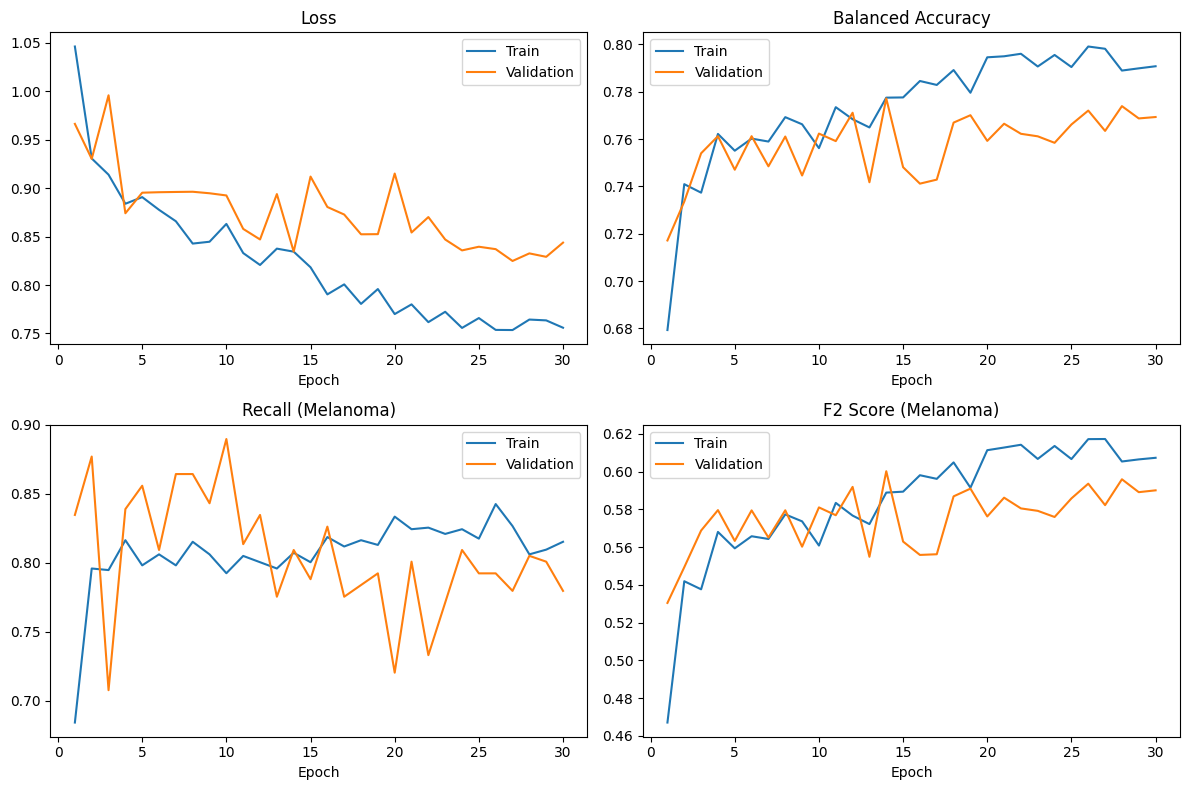

In [7]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [8]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_layer4_2_l1_l2_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.53 | Val F2: 0.6116


## Test Set Evaluation

Threshold:          0.53
AUC-ROC:            0.8460
Balanced Accuracy:  0.7605
F2 Score:           0.5730

              precision    recall  f1-score   support

Non-Melanoma     0.9601    0.7724    0.8561      1340
    Melanoma     0.2956    0.7485    0.4238       171

    accuracy                         0.7697      1511
   macro avg     0.6279    0.7605    0.6400      1511
weighted avg     0.8849    0.7697    0.8072      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


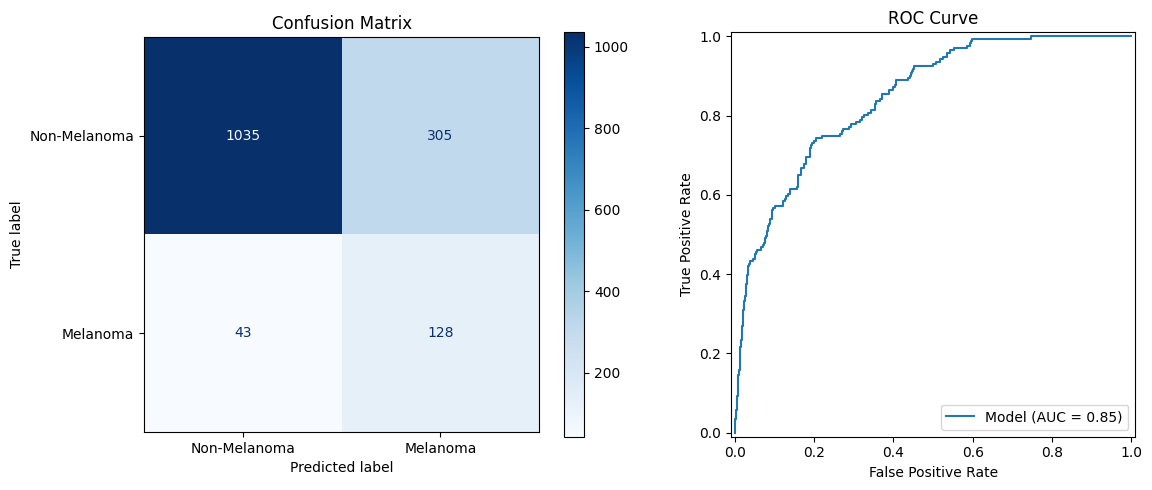

In [9]:
evaluate_model(model, test_loader, device, threshold=best_threshold)